<a href="https://colab.research.google.com/github/Vivian3418/Colab-project/blob/main/NYC_taxi_trip_pattern_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U -q PyDrive
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install pyarrow

In [ ]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [ ]:
#https://drive.google.com/file/d/1r3TQseKrxXA37vasyd8Zgfxsheb5dlqz/view?usp=sharing
fhv_id_23='1r3TQseKrxXA37vasyd8Zgfxsheb5dlqz'
file=drive.CreateFile({'id':fhv_id_23})
file.GetContentFile('fhvhv_tripdata_2023-01.parquet')
fhv_df_23=pq.read_table(f'fhvhv_tripdata_2023-01.parquet').to_pandas()
fhv_df_23.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0003,B03404,B03404,2023-01-01 00:18:06,2023-01-01 00:19:24,2023-01-01 00:19:38,2023-01-01 00:48:07,48,68,0.940,1709,25.950,0.000,0.780,2.300,2.750,0.000,5.220,27.830,N,N,,N,N
1,HV0003,B03404,B03404,2023-01-01 00:48:42,2023-01-01 00:56:20,2023-01-01 00:58:39,2023-01-01 01:33:08,246,163,2.780,2069,60.140,0.000,1.800,5.340,2.750,0.000,0.000,50.150,N,N,,N,N
2,HV0003,B03404,B03404,2023-01-01 00:15:35,2023-01-01 00:20:14,2023-01-01 00:20:27,2023-01-01 00:37:54,9,129,8.810,1047,24.370,0.000,0.730,2.160,0.000,0.000,0.000,20.220,N,N,,N,N
3,HV0003,B03404,B03404,2023-01-01 00:35:24,2023-01-01 00:39:30,2023-01-01 00:41:05,2023-01-01 00:48:16,129,129,0.670,431,13.800,0.000,0.410,1.220,0.000,0.000,0.000,7.900,N,N,,N,N
4,HV0003,B03404,B03404,2023-01-01 00:43:15,2023-01-01 00:51:10,2023-01-01 00:52:47,2023-01-01 01:04:51,129,92,4.380,724,20.490,0.000,0.610,1.820,0.000,0.000,0.000,16.480,N,N,,N,N


# Part 1 Understanding Raw Dataset

In [ ]:
#https://drive.google.com/file/d/14oRJ5x6cTqKF1LVKGOusBGn1GGz7C--p/view?usp=sharing
region_id='14oRJ5x6cTqKF1LVKGOusBGn1GGz7C--p'
file=drive.CreateFile({'id':region_id})
file.GetContentFile(f'taxi_locations.csv')
region_df=pd.read_csv(f'taxi_locations.csv')
region_df.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
import zipfile
geo_id='1XdI0dS_q5Orv-TEvU2cx5nFvpf0VuEkn'
file=drive.CreateFile({'id':geo_id})
file.GetContentFile(f'taxi_zones.zip')
with zipfile.ZipFile('taxi_zones.zip', 'r') as zip_ref:
    zip_ref.extractall('taxi_zones_folder')
zones=gpd.read_file(f'taxi_zones_folder/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116,0.001,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433,0.005,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084,0.000,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.044,0.000,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092,0.000,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [ ]:
zones.to_csv('zones.csv',index=False)
from google.colab import files
files.download('zones.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fhv_df_23.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18479031 entries, 0 to 18479030
Data columns (total 24 columns):
 #   Column                Dtype         
---  ------                -----         
 0   hvfhs_license_num     object        
 1   dispatching_base_num  object        
 2   originating_base_num  object        
 3   request_datetime      datetime64[us]
 4   on_scene_datetime     datetime64[us]
 5   pickup_datetime       datetime64[us]
 6   dropoff_datetime      datetime64[us]
 7   PULocationID          int64         
 8   DOLocationID          int64         
 9   trip_miles            float64       
 10  trip_time             int64         
 11  base_passenger_fare   float64       
 12  tolls                 float64       
 13  bcf                   float64       
 14  sales_tax             float64       
 15  congestion_surcharge  float64       
 16  airport_fee           float64       
 17  tips                  float64       
 18  driver_pay            float64       
 19

In [ ]:
fhv_df = fhv_df_23.sample(n=500000, random_state=42)
fhv_df.drop(columns=['dispatching_base_num', 'originating_base_num','bcf','sales_tax','access_a_ride_flag','wav_request_flag','wav_match_flag'],inplace=True)
fhv_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1445137 to 13397998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   hvfhs_license_num     500000 non-null  object        
 1   request_datetime      500000 non-null  datetime64[us]
 2   on_scene_datetime     367300 non-null  datetime64[us]
 3   pickup_datetime       500000 non-null  datetime64[us]
 4   dropoff_datetime      500000 non-null  datetime64[us]
 5   PULocationID          500000 non-null  int64         
 6   DOLocationID          500000 non-null  int64         
 7   trip_miles            500000 non-null  float64       
 8   trip_time             500000 non-null  int64         
 9   base_passenger_fare   500000 non-null  float64       
 10  tolls                 500000 non-null  float64       
 11  congestion_surcharge  500000 non-null  float64       
 12  airport_fee           500000 non-null  float64       
 

In [ ]:
fhv_df.isnull().sum()

,0
hvfhs_license_num,0
request_datetime,0
on_scene_datetime,132700
pickup_datetime,0
dropoff_datetime,0
PULocationID,0
DOLocationID,0
trip_miles,0
trip_time,0
base_passenger_fare,0


In [ ]:
fhv_df[fhv_df.duplicated()]

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag


In [ ]:
fhv_df.nunique()

,0
hvfhs_license_num,2
request_datetime,446842
on_scene_datetime,338236
pickup_datetime,448554
dropoff_datetime,448574
PULocationID,259
DOLocationID,259
trip_miles,21005
trip_time,5507
base_passenger_fare,12348


In [ ]:
columns=['trip_miles','trip_time','base_passenger_fare','tips','driver_pay']
fhv_df[columns].describe()

,trip_miles,trip_time,base_passenger_fare,tips,driver_pay
count,500000.000,500000.000,500000.000,500000.000,500000.000
mean,4.869,1095.129,21.561,0.978,16.791
std,5.599,742.851,17.925,2.777,14.087
min,0.000,1.000,-39.370,0.000,-28.240
25%,1.550,575.000,10.440,0.000,7.710
50%,2.900,908.000,16.260,0.000,12.630
75%,6.020,1405.250,26.190,0.000,21.010
max,154.711,31207.000,804.100,88.870,564.940


In [ ]:
region_df.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
# Convert locationID into boroughs and zones
fhv_df_DOmerge=region_df[['LocationID','Borough','Zone']].merge(fhv_df,left_on='LocationID',right_on='DOLocationID',how='right')
fhv_df_DOmerge.drop(columns='LocationID',inplace=True)
fhv_df_DOmerge.rename(columns={'Zone':'DOZone','Borough':'DOBorough'},inplace=True)
fhv_df_PUmerge=region_df[['LocationID','Borough','Zone']].merge(fhv_df_DOmerge,left_on='LocationID',right_on='PULocationID',how='right')
fhv_df_PUmerge.drop(columns='LocationID',inplace=True)
fhv_df_PUmerge.rename(columns={'Borough':'PUBorough','Zone':'PUZone'},inplace=True)

In [ ]:
# extract date, week, and hour information from pandas date time value
fhv_df_transform=fhv_df_PUmerge.copy()
fhv_df_transform['request_date'] = fhv_df_transform['request_datetime'].dt.day
fhv_df_transform['request_hour'] = fhv_df_transform['request_datetime'].dt.hour
fhv_df_transform['request_week'] = fhv_df_transform['request_datetime'].dt.day_name()

# Part 2 Exploratory Data Analysis

## Missing Values

In [ ]:
fhv_df_transform.isnull().sum()

,0
PUBorough,21
PUZone,0
DOBorough,19447
DOZone,0
hvfhs_license_num,0
request_datetime,0
on_scene_datetime,132700
pickup_datetime,0
dropoff_datetime,0
PULocationID,0


In [ ]:
fhv_df_transform=fhv_df_transform.dropna(subset=['PUBorough'])
fhv_df_fill=fhv_df_transform.copy()
fhv_df_fill['DOBorough'].fillna(value='Unknown',inplace=True)
fhv_df_fill['on_scene_datetime'].fillna(value='pickup_datetime',inplace=True)

/tmp/ipython-input-2616179799.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fhv_df_fill['DOBorough'].fillna(value='Unknown',inplace=True)
/tmp/ipython-input-2616179799.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

## Explore the distribution of driver pay

In [ ]:
fhv_df_fill['driver_pay'].describe()

,driver_pay
count,499979.000
mean,16.791
std,14.087
min,-28.240
25%,7.710
50%,12.630
75%,21.010
max,564.940


In [ ]:
fhv_df_fill['driver_pay']=fhv_df_fill['driver_pay'].abs()

In [ ]:
fhv_df_fill['driver_pay'].describe()

,driver_pay
count,499979.000
mean,16.792
std,14.087
min,0.000
25%,7.710
50%,12.630
75%,21.010
max,564.940


<Axes: xlabel='driver_pay'>

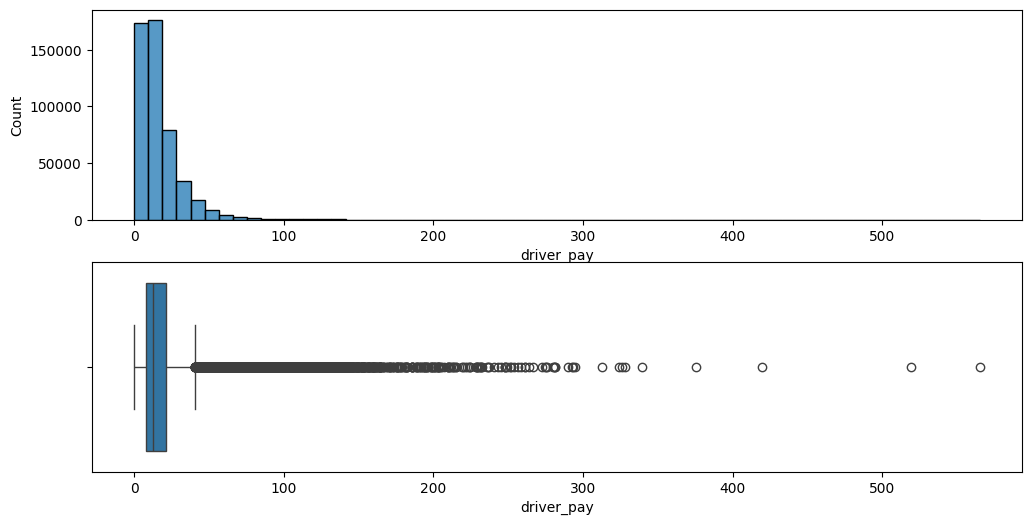

In [ ]:
pay_fig=plt.figure(figsize=(12,6))
ax1=pay_fig.add_subplot(211)
sns.histplot(data=fhv_df_fill,x='driver_pay',bins=60,ax=ax1)

ax2=pay_fig.add_subplot(212)
sns.boxplot(data=fhv_df_fill,x='driver_pay',ax=ax2)

In [ ]:
fhv_df_fill['trip_time'].dtype

dtype('int64')

In [ ]:
corr_lst=['trip_miles','trip_time','base_passenger_fare','tolls','congestion_surcharge','airport_fee','tips','driver_pay']
corr=fhv_df_fill[corr_lst].corr()

<Axes: >

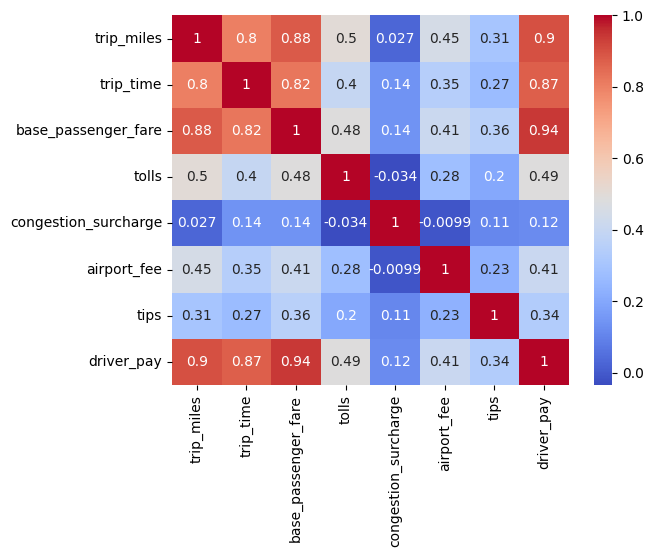

In [ ]:
sns.heatmap(corr,cmap='coolwarm',annot=True)

## 2.1 Understanding numerical features

### Explore the distribution of base passenger fare

In [ ]:
fhv_df_fill['base_passenger_fare'].describe()

,base_passenger_fare
count,499979.000
mean,21.561
std,17.925
min,-39.370
25%,10.440
50%,16.260
75%,26.190
max,804.100


In [ ]:
# replace negative base passenger fare with its absolute value
fhv_df_abs=fhv_df_fill.copy()
fhv_df_abs['base_passenger_fare']=fhv_df_abs['base_passenger_fare'].abs()

In [ ]:
fhv_df_abs['base_passenger_fare'].describe()

,base_passenger_fare
count,499979.000
mean,21.568
std,17.916
min,0.000
25%,10.440
50%,16.260
75%,26.190
max,804.100


In [ ]:
pu_base_fare=fhv_df_abs[['PUBorough','base_passenger_fare']].rename(columns={'PUBorough':'Borough'})
do_base_fare=fhv_df_abs[['DOBorough','base_passenger_fare']].rename(columns={'DOBorough':'Borough'})
base_fare_temp=pd.concat([pu_base_fare,do_base_fare])

In [ ]:
pu_base_fare.sort_values(by='Borough').reset_index().head()

,index,Borough,base_passenger_fare
0,64687,Bronx,12.730
1,444819,Bronx,14.230
2,343654,Bronx,20.470
3,343653,Bronx,22.020
4,198649,Bronx,9.830


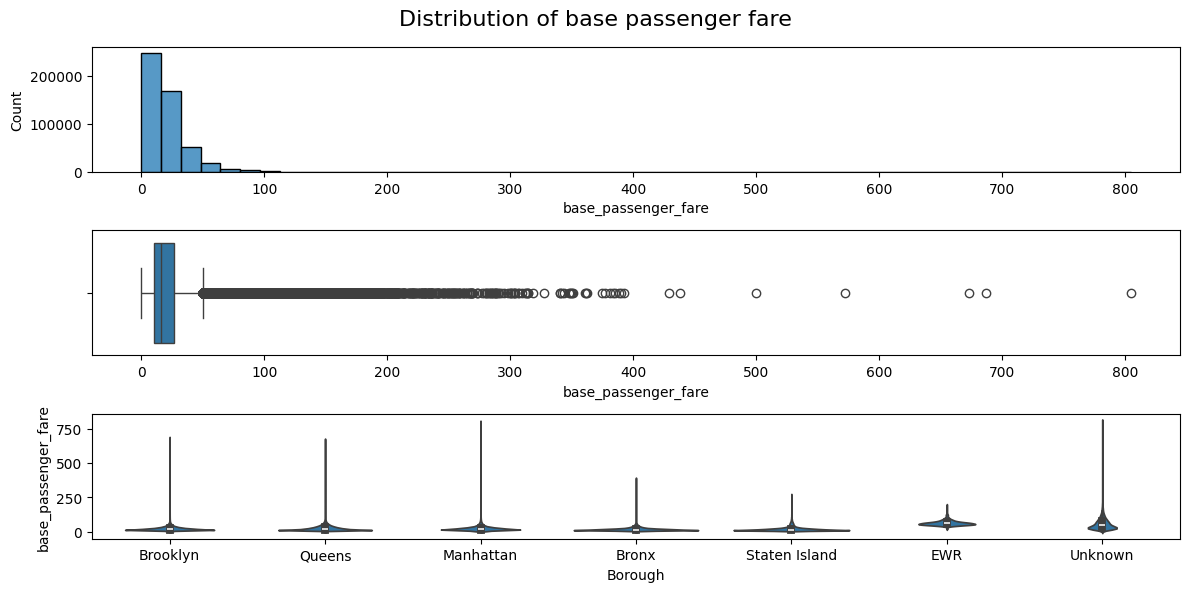

In [ ]:
base_fare_fig=plt.figure(figsize=(12,6))
ax1=base_fare_fig.add_subplot(311)
sns.histplot(data=fhv_df_abs,x='base_passenger_fare',bins=50, ax=ax1)
ax1.set_xlabel('base_passenger_fare')

ax2=base_fare_fig.add_subplot(312)
sns.boxplot(x='base_passenger_fare', data=fhv_df_abs, ax=ax2)
ax2.set_xlabel('base_passenger_fare')

ax3=base_fare_fig.add_subplot(313)
sns.violinplot(x='Borough', y='base_passenger_fare', data=base_fare_temp, ax=ax3)

base_fare_fig.suptitle('Distribution of base passenger fare',fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
fare_by_time=fhv_df_abs.groupby(['request_week','request_hour'])['base_passenger_fare'].median().reset_index()
fare_pivot=fare_by_time.pivot(index='request_week',columns='request_hour',values='base_passenger_fare')
week_orders=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fare_pivot=fare_pivot.reindex(week_orders)

Text(0.5, 1.0, 'Median base passenger fare by weekday and hour')

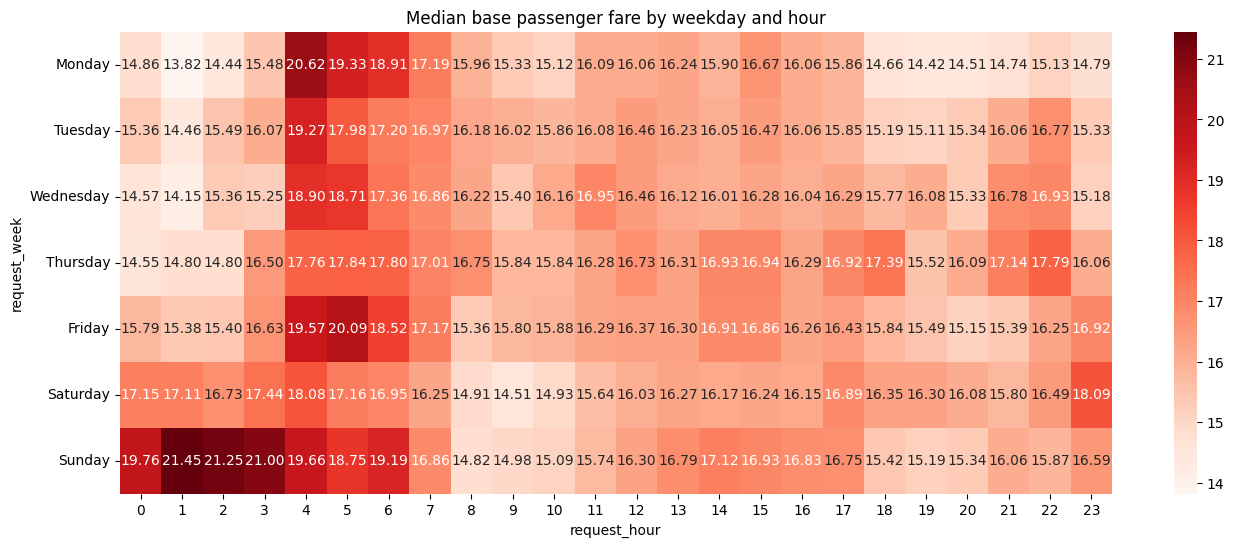

In [ ]:
fare_heatmap=plt.figure(figsize=(16,6))
ax1=fare_heatmap.add_subplot(111)
sns.heatmap(fare_pivot,cmap="Reds",annot=True,fmt='.2f',ax=ax1)
ax1.set_title('Median base passenger fare by weekday and hour')

In [ ]:
pu_median_fare=fhv_df_abs[['PULocationID','base_passenger_fare']].rename(columns={'PULocationID':'zoneID'})
do_median_fare=fhv_df_abs[['DOLocationID','base_passenger_fare']].rename(columns={'DOLocationID':'zoneID'})
fare_by_zone=pd.concat([pu_median_fare,do_median_fare]).groupby('zoneID')['base_passenger_fare'].median().reset_index()
fare_by_zone=fare_by_zone.rename(columns={'base_passenger_fare':'median_base_fare'})
zone_map=zones.merge(fare_by_zone,left_on='LocationID',right_on='zoneID',how='right')

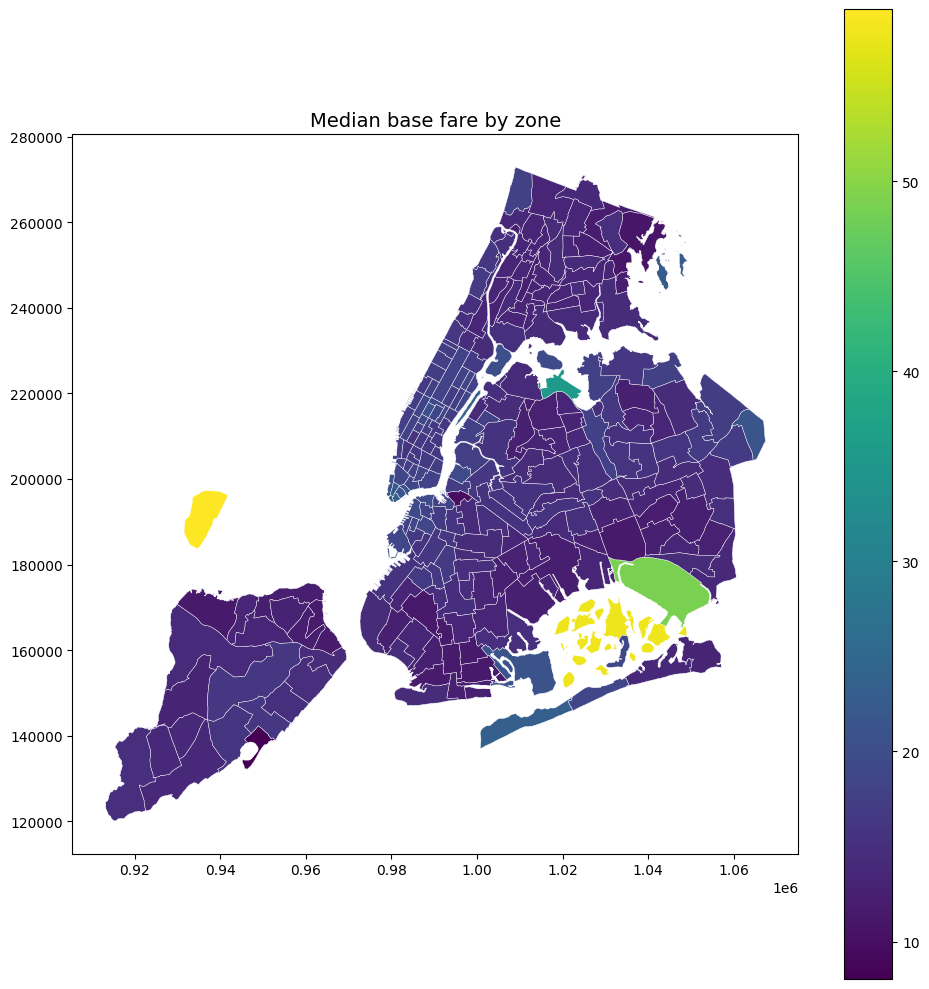

In [ ]:
base_fare_map=plt.figure(figsize=(10,10))
ax=base_fare_map.add_subplot(111)
zone_map.plot(column='median_base_fare',legend=True,edgecolor='white',linewidth=0.3,ax=ax)
ax.set_title('Median base fare by zone',fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
fhv_df_abs.to_csv('fhv_df_abs.csv',index=False)
from google.colab import files
files.download('fhv_df_abs.csv')

KeyboardInterrupt: 

### Explore the distribution of waiting time

In [ ]:
fhv_df_abs['waiting_time_minutes']=(fhv_df_abs['on_scene_datetime']-fhv_df_abs['request_datetime']).dt.total_seconds()
fhv_df_abs['waiting_time_minutes']=fhv_df_abs['waiting_time_minutes']/60
fhv_df_abs[fhv_df_abs['waiting_time_minutes']<0].shape

(1225, 26)

In [ ]:
fhv_df['waiting_time_minutes'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,waiting_time_minutes
count,99995.000
mean,3.678
std,3.658
min,-51.333
10%,0.967
25%,1.817
50%,3.083
75%,4.850
90%,7.267
max,108.067


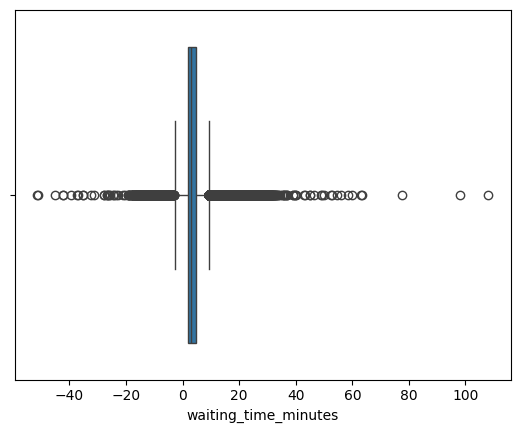

In [ ]:
sns.boxplot(x=fhv_df['waiting_time_minutes'])
plt.show()

In [ ]:
Q1=fhv_df['waiting_time_minutes'].quantile(0.25)
Q3=fhv_df['waiting_time_minutes'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=fhv_df[(fhv_df['waiting_time_minutes']<lower_bound) | (fhv_df['waiting_time_minutes']>upper_bound)]
outliers.shape

(6213, 26)

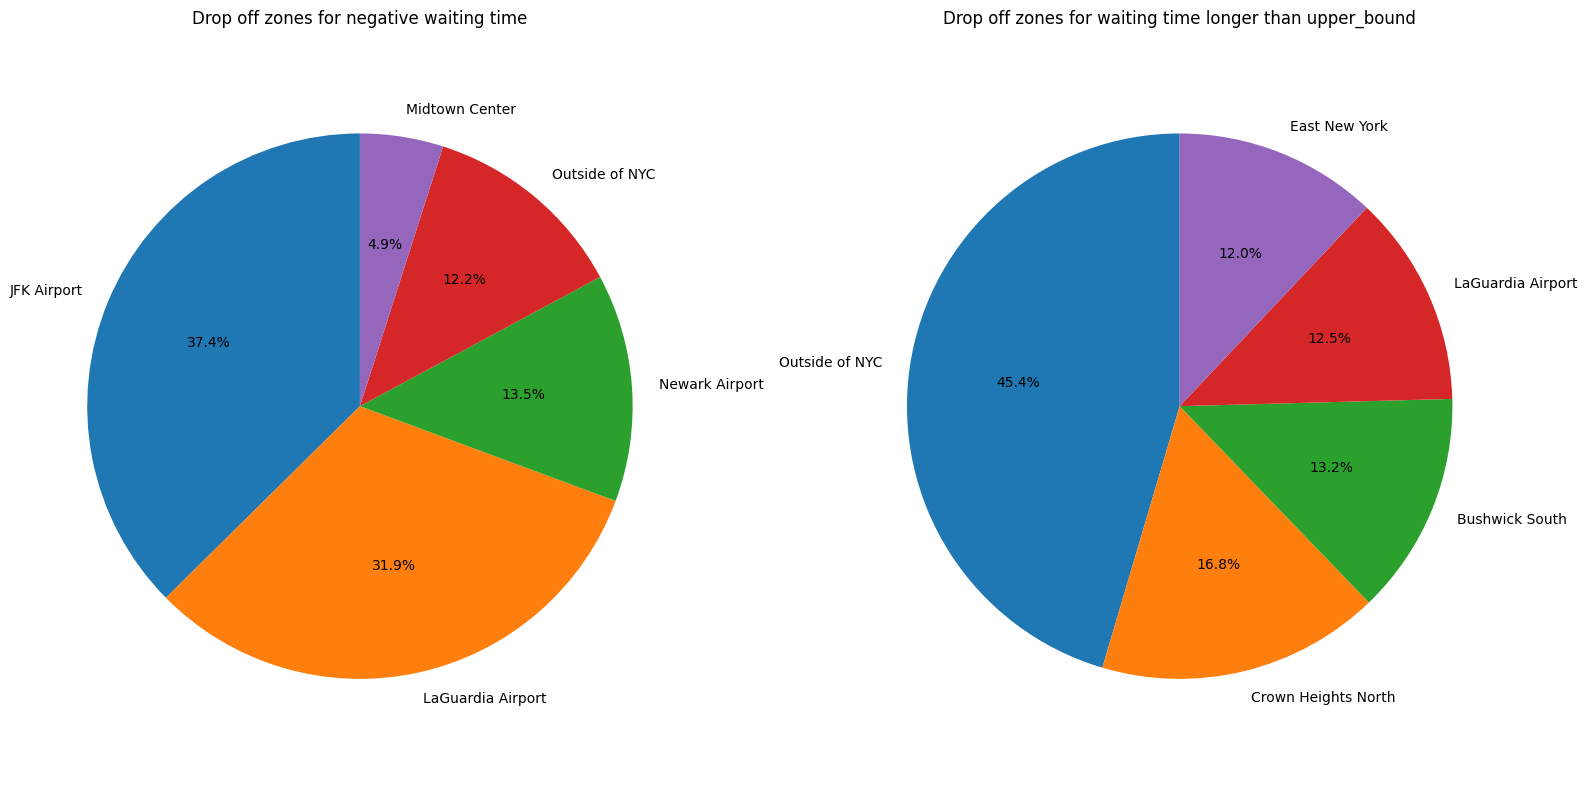

In [ ]:
do_zone_q1=outliers[outliers['waiting_time_minutes']<lower_bound]['DOZone'].value_counts().nlargest(5)
do_zone_q3=outliers[outliers['waiting_time_minutes']>upper_bound]['DOZone'].value_counts().nlargest(5)
fig,axes=plt.subplots(1,2,figsize=(16,8))
axes[0].pie(do_zone_q1,labels=do_zone_q1.index,autopct='%1.1f%%',startangle=90)
axes[0].set_title('Drop off zones for negative waiting time')
axes[0].axis('equal')

axes[1].pie(do_zone_q3,labels=do_zone_q3.index,autopct='%1.1f%%',startangle=90)
axes[1].set_title('Drop-off Zones (Waiting Time > Upper Bound)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

Negative waiting time could be due to prior scheduled trips since about 80% of those trips arrive at the airport.

Nearly half of the trips with long waiting time is destinated outside NYC, drivers might consider unwise to travel such long distance.

In [ ]:
pu=fhv_df[['PUBorough','hour','waiting_time_minutes']].rename(columns={'PUBorough':'Borough'})
do=fhv_df[['DOBorough','hour','waiting_time_minutes']].rename(columns={'DOBorough':'Borough'})
waiting_temp=pd.concat([pu,do],axis=0)
waiting_temp=waiting_temp.groupby(['Borough','hour'])['waiting_time_minutes'].mean().reset_index()

In [ ]:
waiting_pivot=waiting_temp.pivot(index='Borough',columns='hour',values='waiting_time_minutes')
waiting_pivot

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Borough,,,,,,,,,,,,,,,,,,,,,,,,
Bronx,4.702,4.766,4.414,5.490,5.357,4.965,4.929,5.314,3.464,2.870,3.168,2.940,3.409,3.389,3.814,3.840,3.682,3.585,3.714,3.380,3.600,3.832,3.986,4.506
Brooklyn,4.513,5.001,5.385,5.355,4.961,4.354,4.764,5.431,4.198,3.549,3.386,3.502,3.646,3.446,3.740,3.531,3.315,3.603,3.706,3.462,3.327,3.297,3.749,4.180
EWR,2.950,5.333,4.250,2.786,1.495,-0.296,2.120,0.848,3.068,2.098,1.625,2.189,2.931,1.651,2.389,1.699,3.073,2.444,0.894,3.561,3.939,7.206,NaN,4.808
Manhattan,4.348,4.690,4.376,4.533,3.832,3.110,3.777,3.845,3.638,2.654,2.472,2.643,2.869,2.675,2.928,2.835,2.943,3.415,3.398,3.158,2.849,3.457,3.697,4.101
Queens,5.384,5.300,5.011,5.101,4.084,3.374,3.787,4.175,3.466,3.168,3.335,3.257,3.518,3.556,3.707,3.438,3.489,3.796,3.711,3.955,3.894,4.371,4.930,5.033
Staten Island,6.702,5.497,9.011,5.317,6.116,6.208,5.991,5.973,3.865,3.880,4.156,4.357,3.760,3.961,5.124,4.531,4.120,4.645,4.016,4.913,4.433,4.309,5.854,5.642
Unknown,4.511,5.059,4.642,4.982,4.555,4.498,4.156,4.148,3.430,3.560,3.700,3.537,3.505,3.623,3.716,3.949,3.602,3.755,3.585,4.002,3.591,5.073,4.944,4.211


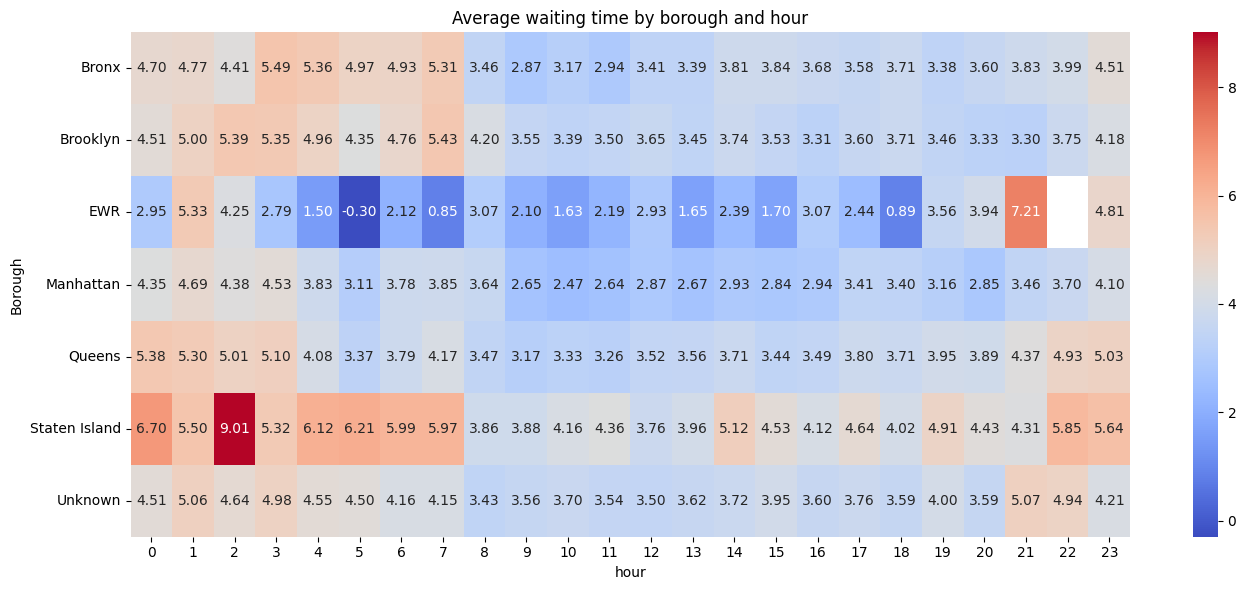

In [ ]:
plt.figure(figsize=(14,6))
ax=sns.heatmap(waiting_pivot,cmap="coolwarm",annot=True,fmt='.2f')
ax.set_xlabel("hour")
ax.set_ylabel("Borough")
ax.set_title('Average waiting time by borough and hour')
plt.tight_layout()
plt.show()

Negative or short waiting time are concentrated in EWR(Newark Liberty International Airport) early in the morning, which indicates that the purpose of these trips is to catch a plane. Long waiting time exist in Staten island early in the morning, probably due to difficulty in finding a taxi in a non-peak hour at suburban area


In [ ]:
print(lower_bound,upper_bound)

-2.7333333333333334 9.399999999999999


In [ ]:
tp=fhv_df[(fhv_df['waiting_time_minutes']<lower_bound) | (fhv_df['waiting_time_minutes']>upper_bound)]
tp.shape

(6213, 26)

<Axes: xlabel='Borough', ylabel='waiting_time_minutes'>

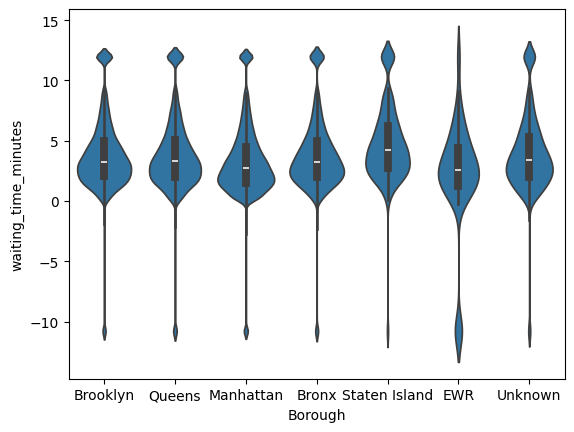

In [ ]:
fhv_df_out=fhv_df.copy()
lower_median=fhv_df.loc[fhv_df['waiting_time_minutes']<lower_bound,'waiting_time_minutes'].median()
upper_median=fhv_df.loc[fhv_df['waiting_time_minutes']>upper_bound,'waiting_time_minutes'].median()
fhv_df_out.loc[(fhv_df_out['waiting_time_minutes']<lower_bound),'waiting_time_minutes']=lower_median
fhv_df_out.loc[(fhv_df_out['waiting_time_minutes']>upper_bound),'waiting_time_minutes']=upper_median
pu_out=fhv_df_out[['PUBorough','waiting_time_minutes']].rename(columns={'PUBorough':'Borough'})
do_out=fhv_df_out[['DOBorough','waiting_time_minutes']].rename(columns={'DOBorough':'Borough'})
waiting_out=pd.concat([pu_out,do_out],axis=0)
sns.violinplot(x='Borough',y='waiting_time_minutes',data=waiting_out)

Distribution of waiting time of dfferenet boroughs are similar, with a peak waiting time between 2-3 minutes, upper tail at 12 minutes and lower tail at about -10 minutes.
Staten island has a higher median value, and EWR has a lower median value.
EWR has a more intensive distribution of negative waitng time between -8 to -12 minutes, which could indicate a pattern of pior scheduled trip at airport.

### Explore the distribution of trip time

In [ ]:
fhv_df_abs['trip_time']=fhv_df_abs['trip_time']/60
fhv_df_abs.rename(columns={'trip_time':'trip_time_mins'},inplace=True)
fhv_df_abs['trip_time_mins'].describe()

,trip_time_mins
count,499979.000
mean,18.252
std,12.381
min,0.017
25%,9.583
50%,15.133
75%,23.417
max,520.117


Text(0.5, 0.98, 'Distribution of trip time')

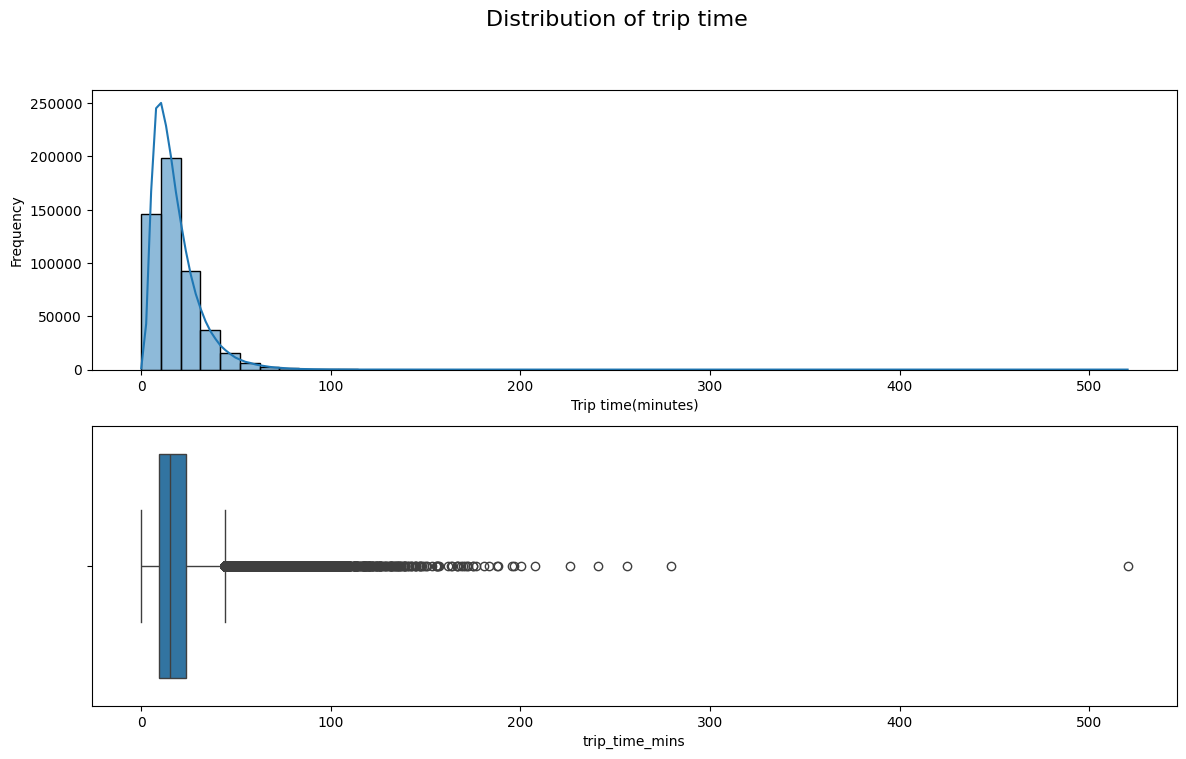

In [ ]:
trip_time_fig=plt.figure(figsize=(14,8))

ax1=trip_time_fig.add_subplot(211)
sns.histplot(fhv_df_abs['trip_time_mins'],bins=50,kde=True,ax=ax1)
ax1.set_xlabel('Trip time(minutes)')
ax1.set_ylabel('Frequency')

ax0=trip_time_fig.add_subplot(212)
sns.boxplot(x=fhv_df_abs['trip_time_mins'],ax=ax0)

trip_time_fig.suptitle('Distribution of trip time',fontsize=16)

In [ ]:
time_Q3=fhv_df_abs['trip_time_mins'].quantile(0.75)
time_Q1=fhv_df_abs['trip_time_mins'].quantile(0.25)
IQR=time_Q3-time_Q1
time_upper=time_Q3+1.5*IQR
fhv_df_abs.loc[fhv_df_abs['trip_time_mins']>time_upper,'trip_time_mins']=time_upper

In [ ]:
fhv_df_abs['trip_time_mins'].describe()

,trip_time_mins
count,499979.000
mean,17.737
std,10.585
min,0.017
25%,9.583
50%,15.133
75%,23.417
max,44.167


([<matplotlib.patches.Wedge at 0x7c4d03725ee0>,
 [Text(0.8621065441571337, 0.6832073671451767, '0-10 minutes'),
  Text(-0.9035739974409122, 0.6273388487481472, '10-20 minutes'),
  Text(-0.33261794223359165, -1.0485062253054538, '20-30 minutes'),
  Text(0.7003519512698105, -0.8482376697321153, '30-40 minutes'),
  Text(1.0572688957766998, -0.30361568145126816, '40-50 minutes')],
 [Text(0.47023993317661833, 0.3726585638973691, '21.3%'),
  Text(-0.4928585440586793, 0.3421848265898984, '38.0%'),
  Text(-0.18142796849104997, -0.5719124865302475, '21.5%'),
  Text(0.3820101552380784, -0.46267509258115375, '10.2%'),
  Text(0.5766921249691089, -0.16560855351887352, '8.9%')])

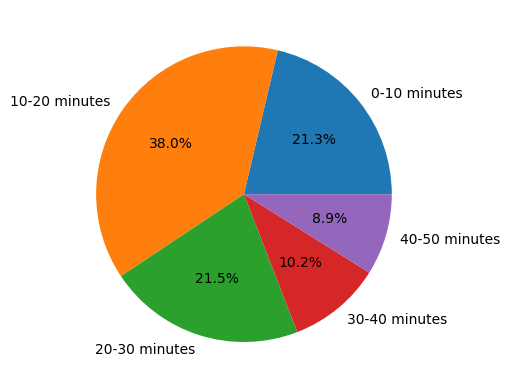

In [ ]:
pie_chart=plt.figure(figsize=(10,6))
ax1=pie_chart.add_subplot(121)
timebin_labels=['0-10 minutes','10-20 minutes','20-30 minutes','30-40 minutes','40-50 minutes']
time_bin=pd.cut(fhv_df_abs['trip_time_mins'],5,labels=timebin_labels)
plt.pie(time_bin.value_counts().sort_index(),labels=timebin_labels,autopct='%1.1f%%',ax=ax1)

distancebin_labels=['0-10 minutes','10-20 minutes','20-30 minutes','30-40 minutes','40-50 minutes']


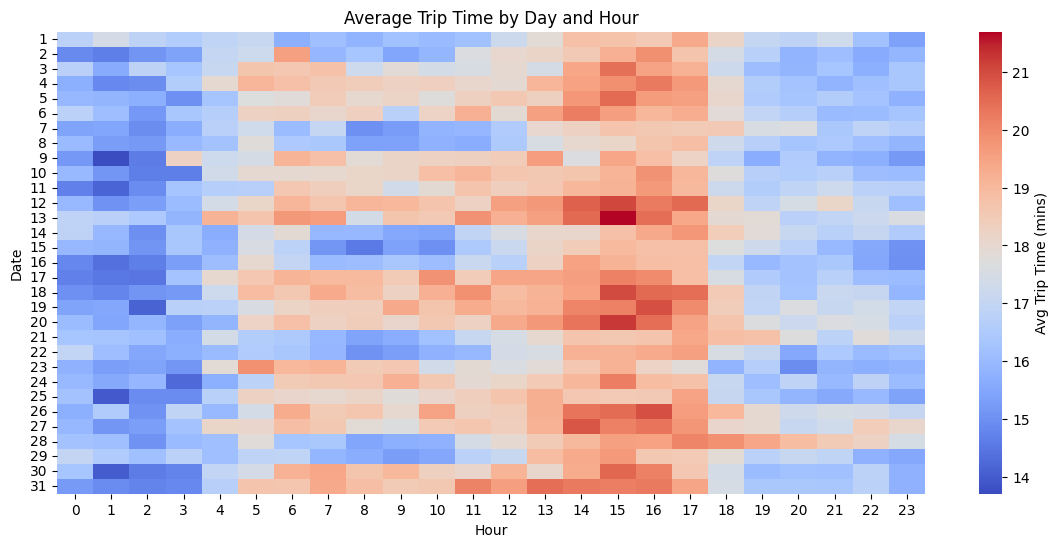

In [ ]:
time_by_day=fhv_df_abs.groupby(['request_date','request_hour'])['trip_time_mins'].mean().reset_index()
pivot = time_by_day.pivot(index='request_date', columns='request_hour', values='trip_time_mins')

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='coolwarm', annot=False, cbar_kws={'label': 'Avg Trip Time (mins)'})
plt.title("Average Trip Time by Day and Hour")
plt.ylabel("Date")
plt.xlabel("Hour")
plt.show()

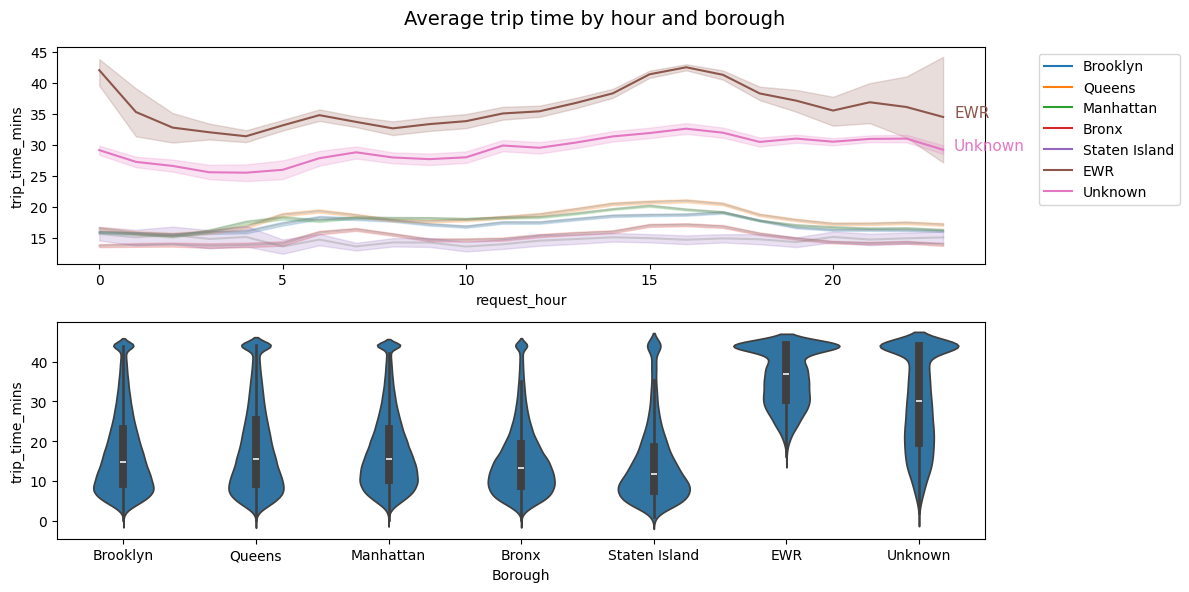

In [ ]:
pu_time=fhv_df_abs[['PUBorough','request_hour','request_week','trip_time_mins']].rename(columns={'PUBorough':'Borough'})
do_time=fhv_df_abs[['DOBorough','request_hour','request_week','trip_time_mins']].rename(columns={'DOBorough':'Borough'})
time_temp=pd.concat([pu_time,do_time])

time_pattern=plt.figure(figsize=(12,6))
ax0=time_pattern.add_subplot(211)
sns.lineplot(x='request_hour',y='trip_time_mins',hue='Borough',data=time_temp,ax=ax0)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')

for line, borough in zip(ax0.lines,time_temp['Borough'].unique()):
  if borough not in ['EWR','Unknown']:
    line.set_alpha(0.3)
    line.set_color('gray')
  else:
    line.set_alpha(1.0)
    x,y=line.get_xdata()[-1],line.get_ydata()[-1]
    ax0.text(x+0.3, y, borough, color=line.get_color(), fontsize=11)


ax1=time_pattern.add_subplot(212)
sns.violinplot(x='Borough',y='trip_time_mins',data=time_temp,ax=ax1)

time_pattern.suptitle('Average trip time by hour and borough',fontsize=14)
plt.tight_layout()
plt.show()

The trip time is concentrated at 8 - 10 minutes, with median trip time of about 15 minutes. Trips at EWR has a higher than average trip time at about 35 minutes, probably because the airport is far away from urban area.

###Explore the distribution of trip distance

In [ ]:
fhv_df_miles=fhv_df_abs.drop(fhv_df_abs[fhv_df_abs['trip_miles']==0].index)

In [ ]:
fhv_df_miles['trip_miles'].describe()

,trip_miles
count,499888.000
mean,4.869
std,5.599
min,0.007
25%,1.550
50%,2.900
75%,6.020
max,154.711


Text(0.5, 0.98, 'Distribution of trip time')

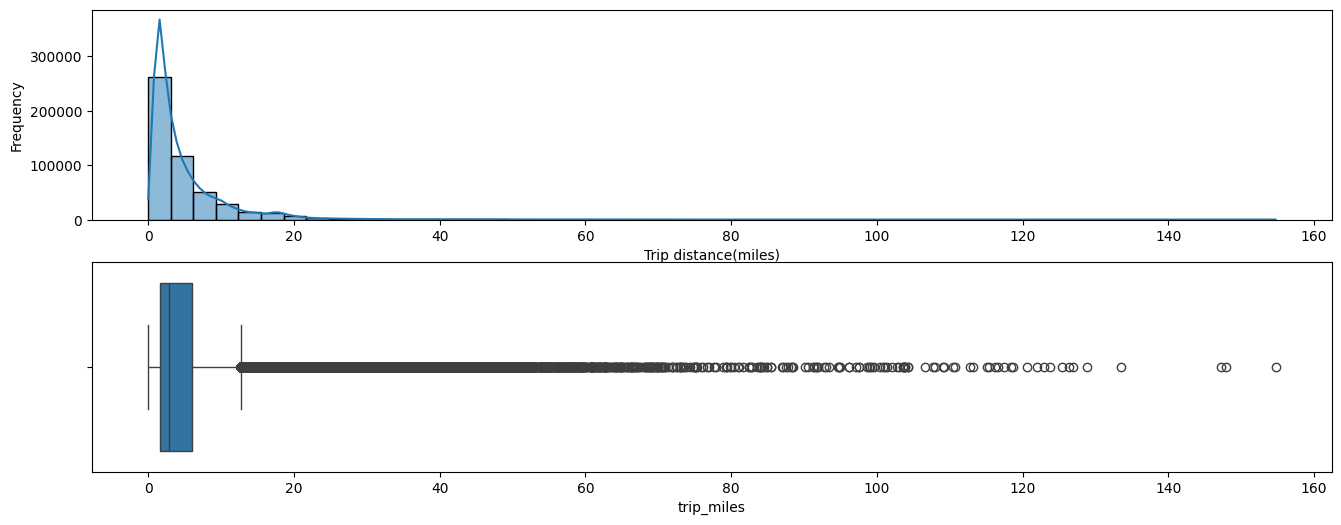

In [ ]:
distance_fig=plt.figure(figsize=(16,6))

ax0=distance_fig.add_subplot(211)
sns.histplot(fhv_df_abs['trip_miles'],bins=50,kde=True,ax=ax0)
ax0.set_xlabel('Trip distance(miles)')
ax0.set_ylabel('Frequency')

ax1=distance_fig.add_subplot(212)
sns.boxplot(x=fhv_df_abs['trip_miles'],ax=ax1)

trip_time_fig.suptitle('Distribution of trip time',fontsize=16)

<Axes: xlabel='hourbin', ylabel='trip_miles'>

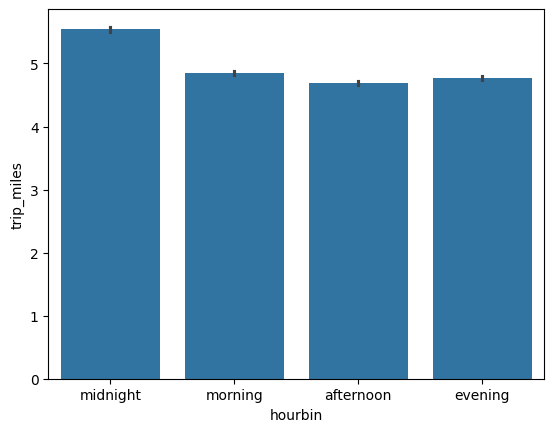

In [ ]:
hour_labels=['midnight','morning','afternoon','evening']
hour_bins=pd.cut(fhv_df_miles['request_hour'],4,labels=hour_labels)
fhv_df_hourbins=fhv_df_miles.copy()
fhv_df_hourbins['hourbin']=hour_bins.values
sns.barplot(fhv_df_hourbins,x='hourbin',y='trip_miles')


# pie_chart=plt.figure(figsize=(10,6))
# ax1=pie_chart.add_subplot(121)
# timebin_labels=['0-10 minutes','10-20 minutes','20-30 minutes','30-40 minutes','40-50 minutes']
# time_bin=pd.cut(fhv_df_abs['trip_time_mins'],5,labels=timebin_labels)
# plt.pie(time_bin.value_counts().sort_index(),labels=timebin_labels,autopct='%1.1f%%',ax=ax1)


In [ ]:
fhv_df_hourbins.head()

,PUBorough,PUZone,DOBorough,DOZone,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time_mins,base_passenger_fare,tolls,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,request_date,request_hour,request_week,hourbin
0,Brooklyn,Gravesend,Brooklyn,Coney Island,HV0003,2023-01-03 20:00:53,2023-01-03 20:05:02,2023-01-03 20:05:22,2023-01-03 20:16:03,108,55,2.360,10.683,11.580,0.000,0.000,0.000,1.000,8.400,N,N,3,20,Tuesday,evening
1,Queens,Woodside,Queens,Jackson Heights,HV0003,2023-01-24 19:01:16,2023-01-24 19:03:40,2023-01-24 19:05:41,2023-01-24 19:14:33,260,129,0.880,8.867,9.500,0.000,0.000,0.000,0.000,6.590,N,N,24,19,Tuesday,evening
2,Manhattan,Murray Hill,Manhattan,Two Bridges/Seward Park,HV0003,2023-01-07 23:32:36,2023-01-07 23:33:20,2023-01-07 23:35:20,2023-01-07 23:49:52,170,232,2.940,14.533,14.790,0.000,2.750,0.000,0.000,11.120,N,N,7,23,Saturday,evening
3,Manhattan,East Chelsea,Manhattan,West Chelsea/Hudson Yards,HV0005,2023-01-15 17:58:21,pickup_datetime,2023-01-15 18:04:10,2023-01-15 18:12:23,68,246,1.432,8.217,11.650,0.000,2.750,0.000,0.000,6.040,N,N,15,17,Sunday,afternoon
4,Queens,Steinway,Queens,Steinway,HV0005,2023-01-23 08:22:06,pickup_datetime,2023-01-23 08:27:12,2023-01-23 08:35:11,223,223,1.507,7.983,7.810,0.000,0.000,0.000,0.000,6.010,N,N,23,8,Monday,morning


In [ ]:
hour_bins.shape

(499979,)

In [ ]:
fhv_df_hourbins.shape

(499888, 24)

In [ ]:
pu_miles=fhv_df_miles[['PUBorough','request_hour','request_week','trip_miles']].rename(columns={'PUBorough':'Borough'})
do_miles=fhv_df_miles[['DOBorough','request_hour','request_week','trip_miles']].rename(columns={'DOBorough':'Borough'})
miles_temp=pd.concat([pu_miles,do_miles])
miles_by_time=miles_temp.groupby(['Borough','request_hour'])['trip_miles'].mean().reset_index()
miles_by_time=miles_by_time.rename(columns={'trip_miles':'mean_trip_miles'})
miles_pivot=miles_by_time.pivot(index='Borough',columns='request_hour',values='mean_trip_miles')

<Axes: xlabel='Borough', ylabel='trip_miles'>

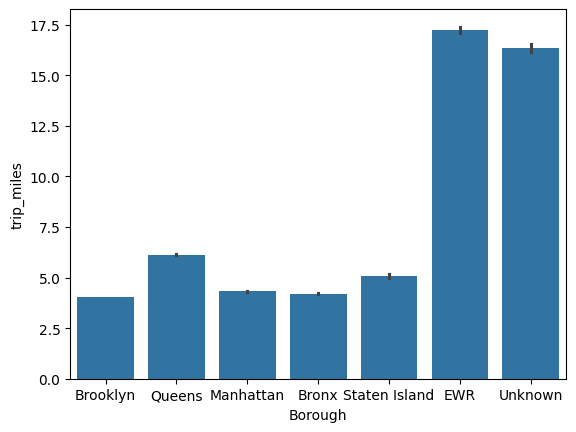

In [ ]:
sns.barplot(miles_temp,x='Borough',y='trip_miles')

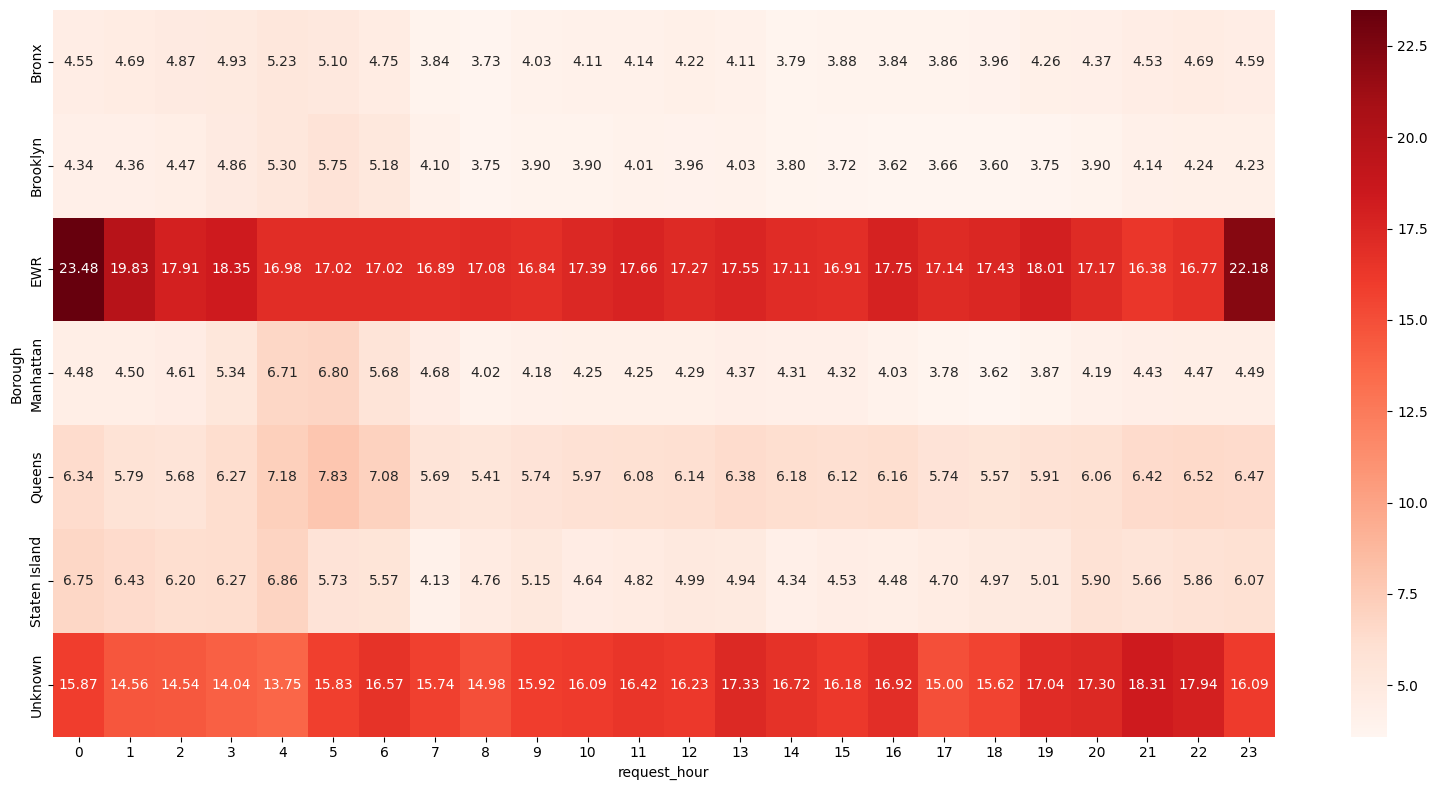

In [ ]:
miles_heatmap=plt.figure(figsize=(16,8))
ax=miles_heatmap.add_subplot(111)
sns.heatmap(miles_pivot,cmap="Reds",annot=True,fmt='.2f')
plt.tight_layout()
plt.show()

<Axes: xlabel='time_bin', ylabel='speed'>

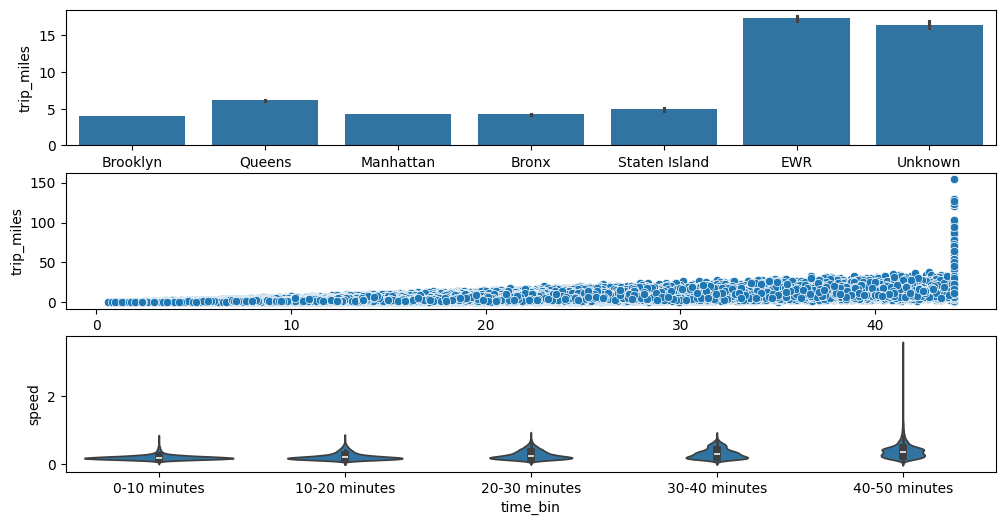

In [ ]:
pu_miles=fhv_df_miles[['PUBorough','hour','day_category','trip_miles']].rename(columns={'PUBorough':'Borough'})
do_miles=fhv_df_miles[['DOBorough','hour','day_category','trip_miles']].rename(columns={'DOBorough':'Borough'})
miles_temp=pd.concat([pu_miles,do_miles])

fhv_df_miles['time_bin']=time_bin
fhv_df_miles['speed']=fhv_df_miles['trip_miles']/fhv_df_miles['trip_time_mins']

distance_pattern=plt.figure(figsize=(12,6))

ax0=distance_pattern.add_subplot(311)
sns.barplot(x='Borough',y='trip_miles',data=miles_temp,ax=ax0)

ax1=distance_pattern.add_subplot(312)
sns.scatterplot(x='trip_time_mins',y='trip_miles',data=fhv_df_miles,ax=ax1)

ax2=distance_pattern.add_subplot(313)
sns.violinplot(x='time_bin',y='speed',data=fhv_df_miles,ax=ax2)

right skewed trip time, with most data concentrate between 10 to 40 minutes, and a few trips extending beyond 50 minutes

## 2.2 Understanding categorical features

### Distribution of driver_pay by time

In [ ]:
fhv_df_date=fhv_df_miles.copy()
def categorize_day(day):
  if day<=10:
    return 'start_month'
  elif day<=20:
    return 'mid_month'
  else:
    return 'end_month'
fhv_df_date['date_category']=fhv_df_date['request_date'].apply(categorize_day)
day_category_encoded=pd.get_dummies(fhv_df_date['date_category'],prefix='date')
fhv_df_date=pd.concat([fhv_df_date,day_category_encoded],axis=1)
fhv_df_date.head()

,PUBorough,PUZone,DOBorough,DOZone,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time_mins,base_passenger_fare,tolls,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,request_date,request_hour,request_week,date_category,date_end_month,date_mid_month,date_start_month
0,Brooklyn,Gravesend,Brooklyn,Coney Island,HV0003,2023-01-03 20:00:53,2023-01-03 20:05:02,2023-01-03 20:05:22,2023-01-03 20:16:03,108,55,2.360,10.683,11.580,0.000,0.000,0.000,1.000,8.400,N,N,3,20,Tuesday,start_month,False,False,True
1,Queens,Woodside,Queens,Jackson Heights,HV0003,2023-01-24 19:01:16,2023-01-24 19:03:40,2023-01-24 19:05:41,2023-01-24 19:14:33,260,129,0.880,8.867,9.500,0.000,0.000,0.000,0.000,6.590,N,N,24,19,Tuesday,end_month,True,False,False
2,Manhattan,Murray Hill,Manhattan,Two Bridges/Seward Park,HV0003,2023-01-07 23:32:36,2023-01-07 23:33:20,2023-01-07 23:35:20,2023-01-07 23:49:52,170,232,2.940,14.533,14.790,0.000,2.750,0.000,0.000,11.120,N,N,7,23,Saturday,start_month,False,False,True
3,Manhattan,East Chelsea,Manhattan,West Chelsea/Hudson Yards,HV0005,2023-01-15 17:58:21,pickup_datetime,2023-01-15 18:04:10,2023-01-15 18:12:23,68,246,1.432,8.217,11.650,0.000,2.750,0.000,0.000,6.040,N,N,15,17,Sunday,mid_month,False,True,False
4,Queens,Steinway,Queens,Steinway,HV0005,2023-01-23 08:22:06,pickup_datetime,2023-01-23 08:27:12,2023-01-23 08:35:11,223,223,1.507,7.983,7.810,0.000,0.000,0.000,0.000,6.010,N,N,23,8,Monday,end_month,True,False,False


<Axes: xlabel='date_category', ylabel='driver_pay'>

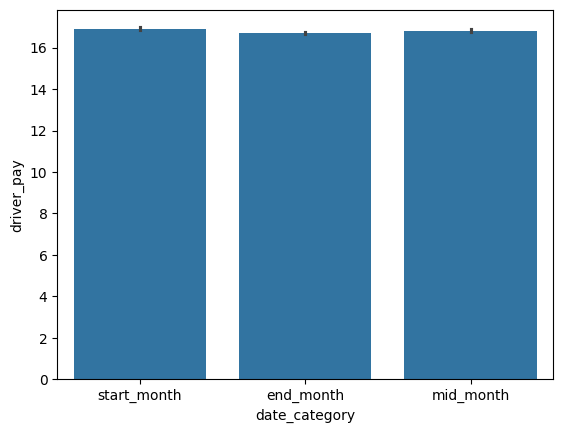

In [ ]:
sns.barplot(fhv_df_date,x='date_category',y='driver_pay')

In [ ]:
fhv_df_weekday=fhv_df_date.copy()
weekday_category_encoded=pd.get_dummies(fhv_df_weekday['request_week'])
fhv_df_weekday=pd.concat([fhv_df_weekday,weekday_category_encoded],axis=1)

<Axes: xlabel='request_week', ylabel='driver_pay'>

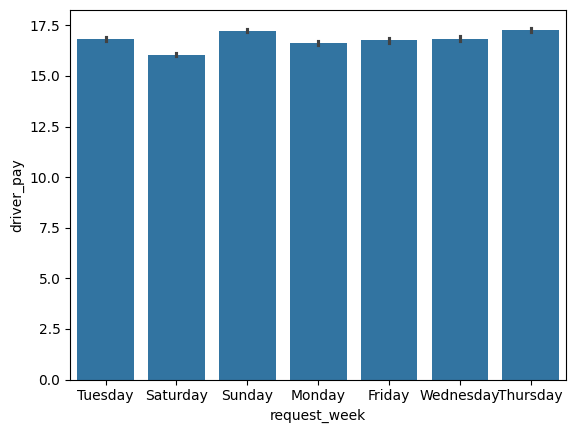

In [ ]:
sns.barplot(fhv_df_weekday,x='request_week',y='driver_pay')

In [ ]:
fhv_df_hour=fhv_df_weekday.copy()
labels = ['midnight','morning','afternoon','evening']
bins   = [0, 5, 11, 17, 24]
fhv_df_hour['hour_category']=pd.cut(fhv_df_hour['request_hour'],bins=bins,labels=labels,include_lowest=True)
hour_category_encoded=pd.get_dummies(fhv_df_hour['hour_category'],prefix='hour')
fhv_df_hour=pd.concat([fhv_df_hour,hour_category_encoded],axis=1)
fhv_df_hour.head()

,PUBorough,PUZone,DOBorough,DOZone,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time_mins,base_passenger_fare,tolls,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,request_date,request_hour,request_week,date_category,date_end_month,date_mid_month,date_start_month,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,hour_category,hour_midnight,hour_morning,hour_afternoon,hour_evening
0,Brooklyn,Gravesend,Brooklyn,Coney Island,HV0003,2023-01-03 20:00:53,2023-01-03 20:05:02,2023-01-03 20:05:22,2023-01-03 20:16:03,108,55,2.360,10.683,11.580,0.000,0.000,0.000,1.000,8.400,N,N,3,20,Tuesday,start_month,False,False,True,False,False,False,False,False,True,False,evening,False,False,False,True
1,Queens,Woodside,Queens,Jackson Heights,HV0003,2023-01-24 19:01:16,2023-01-24 19:03:40,2023-01-24 19:05:41,2023-01-24 19:14:33,260,129,0.880,8.867,9.500,0.000,0.000,0.000,0.000,6.590,N,N,24,19,Tuesday,end_month,True,False,False,False,False,False,False,False,True,False,evening,False,False,False,True
2,Manhattan,Murray Hill,Manhattan,Two Bridges/Seward Park,HV0003,2023-01-07 23:32:36,2023-01-07 23:33:20,2023-01-07 23:35:20,2023-01-07 23:49:52,170,232,2.940,14.533,14.790,0.000,2.750,0.000,0.000,11.120,N,N,7,23,Saturday,start_month,False,False,True,False,False,True,False,False,False,False,evening,False,False,False,True
3,Manhattan,East Chelsea,Manhattan,West Chelsea/Hudson Yards,HV0005,2023-01-15 17:58:21,pickup_datetime,2023-01-15 18:04:10,2023-01-15 18:12:23,68,246,1.432,8.217,11.650,0.000,2.750,0.000,0.000,6.040,N,N,15,17,Sunday,mid_month,False,True,False,False,False,False,True,False,False,False,afternoon,False,False,True,False
4,Queens,Steinway,Queens,Steinway,HV0005,2023-01-23 08:22:06,pickup_datetime,2023-01-23 08:27:12,2023-01-23 08:35:11,223,223,1.507,7.983,7.810,0.000,0.000,0.000,0.000,6.010,N,N,23,8,Monday,end_month,True,False,False,False,True,False,False,False,False,False,morning,False,True,False,False


<Axes: xlabel='hour_category', ylabel='driver_pay'>

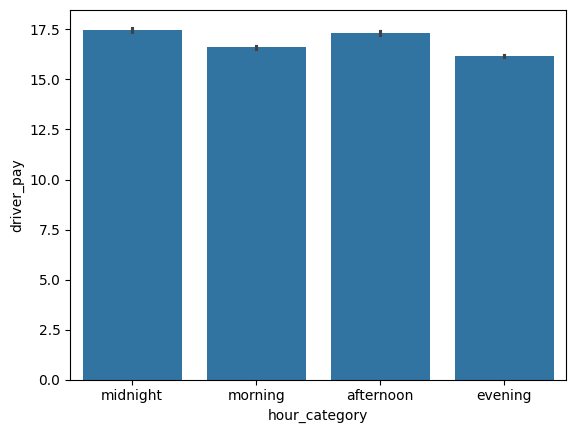

In [ ]:
sns.barplot(fhv_df_hour,x='hour_category',y='driver_pay')
# 改成bar plot

### Distribution of driver_pay by region

In [ ]:
fhv_df_borough.columns

Index(['PUBorough', 'PUZone', 'DOBorough', 'DOZone', 'hvfhs_license_num',
       'request_datetime', 'on_scene_datetime', 'pickup_datetime',
       'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles',
       'trip_time_mins', 'base_passenger_fare', 'tolls',
       'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay',
       'shared_request_flag', 'shared_match_flag', 'request_date',
       'request_hour', 'request_week', 'date_category', 'date_end_month',
       'date_mid_month', 'date_start_month', 'Friday', 'Monday', 'Saturday',
       'Sunday', 'Thursday', 'Tuesday', 'Wednesday', 'hour_category',
       'hour_midnight', 'hour_morning', 'hour_afternoon', 'hour_evening'],
      dtype='object')

<Axes: xlabel='Borough', ylabel='driver_pay'>

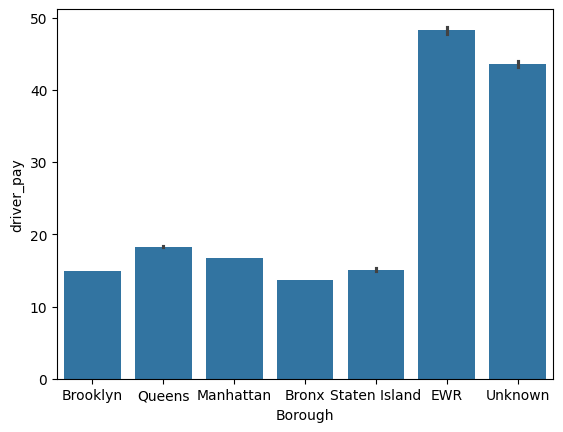

In [ ]:
fhv_df_borough=fhv_df_hour.copy()
pu_temp=fhv_df_borough[['PUBorough','driver_pay']].rename(columns={'PUBorough':'Borough'})
do_temp=fhv_df_borough[['DOBorough','driver_pay']].rename(columns={'DOBorough':'Borough'})
borough_temp=pd.concat([pu_temp,do_temp])
sns.barplot(borough_temp,x='Borough',y='driver_pay')
# driver pay by zone

In [ ]:
fhv_df_clean=fhv_df_miles.copy()
fhv_df_clean['trip_time_log']=np.log1p(fhv_df_miles['trip_time_mins'])

In [ ]:
fhv_df_clean=fhv_df_clean.drop(['hvfhs_license_num','request_datetime','on_scene_datetime','pickup_datetime','dropoff_datetime','PULocationID','DOLocationID','tolls','congestion_surcharge','airport_fee','shared_request_flag','shared_match_flag','time_bin'],axis=1)

In [ ]:
fhv_df_clean=fhv_df_clean.drop(['trip_time_mins','waiting_time_minutes'],axis=1)

In [ ]:
fhv_df_clean.head()

,trip_miles,base_passenger_fare,tips,driver_pay,day,hour,weekday,day_category,PUBorough,PUZone,DOBorough,DOZone,speed,trip_time_log
0,2.360,11.580,1.000,8.400,3,20,1,weekday,Brooklyn,Gravesend,Brooklyn,Coney Island,0.221,2.458
1,0.880,9.500,0.000,6.590,24,19,1,weekday,Queens,Woodside,Queens,Jackson Heights,0.099,2.289
2,2.940,14.790,0.000,11.120,7,23,5,weekday,Manhattan,Murray Hill,Manhattan,Two Bridges/Seward Park,0.202,2.743
3,1.432,11.650,0.000,6.040,15,17,6,weekend,Manhattan,East Chelsea,Manhattan,West Chelsea/Hudson Yards,0.174,2.221
4,1.507,7.810,0.000,6.010,23,8,0,weekday,Queens,Steinway,Queens,Steinway,0.189,2.195


In [ ]:
PUBorough_encoded=pd.get_dummies(fhv_df_clean['PUBorough'],prefix='PU')
fhv_df_clean=pd.concat([fhv_df_clean,PUBorough_encoded],axis=1)
DOBorough_encoded=pd.get_dummies(fhv_df_clean['DOBorough'],prefix='DO')
fhv_df_clean=pd.concat([fhv_df_clean,DOBorough_encoded],axis=1)

In [ ]:
fhv_df_clean.columns

Index(['trip_miles', 'base_passenger_fare', 'tips', 'driver_pay', 'day',
       'hour', 'weekday', 'day_category', 'PUBorough', 'PUZone', 'DOBorough',
       'DOZone', 'speed', 'trip_time_log', 'day_end_month', 'day_mid_month',
       'day_start_month', 'hour_category', 'hour_midnight', 'hour_morning',
       'hour_afternoon', 'hour_evening', 'weekday_category', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'PU_Bronx', 'PU_Brooklyn', 'PU_Manhattan', 'PU_Queens',
       'PU_Staten Island', 'DO_Bronx', 'DO_Brooklyn', 'DO_EWR', 'DO_Manhattan',
       'DO_Queens', 'DO_Staten Island', 'DO_Unknown', 'Bronx', 'Brooklyn',
       'Manhattan', 'Queens', 'Staten Island'],
      dtype='object')

In [ ]:
fhv_df_clean.drop(columns=['weekday_category'],axis=1,inplace=True)

In [ ]:
fhv_df_drop=fhv_df_clean.drop(columns=['day','hour','weekday','PUBorough','PUZone','DOBorough','DOZone','day_category','hour_category',
                  ],axis=1)

Index(['trip_miles', 'base_passenger_fare', 'tips', 'driver_pay', 'speed',
       'trip_time_log', 'day_end_month', 'day_mid_month', 'day_start_month',
       'hour_midnight', 'hour_morning', 'hour_afternoon', 'hour_evening',
       'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday', 'PU_Bronx', 'PU_Brooklyn', 'PU_Manhattan', 'PU_Queens',
       'PU_Staten Island', 'DO_Bronx', 'DO_Brooklyn', 'DO_EWR', 'DO_Manhattan',
       'DO_Queens', 'DO_Staten Island', 'DO_Unknown', 'Bronx', 'Brooklyn',
       'Manhattan', 'Queens', 'Staten Island'],
      dtype='object')

In [ ]:
fhv_df_drop.drop(columns=['Bronx', 'Brooklyn',
       'Manhattan', 'Queens', 'Staten Island'],axis=1,inplace=True)

In [ ]:
fhv_df_drop.columns

Index(['trip_miles', 'base_passenger_fare', 'tips', 'driver_pay', 'speed',
       'trip_time_log', 'day_end_month', 'day_mid_month', 'day_start_month',
       'hour_midnight', 'hour_morning', 'hour_afternoon', 'hour_evening',
       'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday', 'PU_Bronx', 'PU_Brooklyn', 'PU_Manhattan', 'PU_Queens',
       'PU_Staten Island', 'DO_Bronx', 'DO_Brooklyn', 'DO_EWR', 'DO_Manhattan',
       'DO_Queens', 'DO_Staten Island', 'DO_Unknown'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train, y_test=train_test_split(fhv_df_drop.drop(['driver_pay'],axis=1),fhv_df_drop['driver_pay'],test_size=0.2,random_state=27)

## Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scale_lst=['trip_miles','trip_time_log','base_passenger_fare','tips','speed']
scaler=StandardScaler()
scaler.fit(x_train[scale_lst])
x_train[scale_lst]=scaler.transform(x_train[scale_lst])
x_test[scale_lst]=scaler.transform(x_test[scale_lst])

# Part 3 Model training

In [ ]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import root_mean_squared_error,r2_score
y_pred=reg.predict(x_test)
rmse=root_mean_squared_error(y_pred,y_test)
print('Root mean squared error of Ridge regression:',rmse)
r2=r2_score(y_test,y_pred)
print('R squared score of Ridge regression:',r2)

Root mean squared error of Ridge regression: 3.810341049182152
R squared score of Ridge regression: 0.9268059841837291


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
param_grid={
    'alpha':[0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_search_reg=GridSearchCV(Ridge(),param_grid,cv=5,scoring='neg_mean_squared_error',refit=True) #返回一个gridsearch的对象，括号里定义它从哪里和怎么去挑选模型，挑选完后是否要用最优参数重新训练模型
grid_search_reg.fit(x_train,y_train)
best_alpha=grid_search_reg.best_params_
print('best alpha for Ridge regression is',best_alpha)

best alpha for Ridge regression is {'alpha': 10}


In [ ]:
best_model=grid_search_reg.best_estimator_
new_y_predict=best_model.predict(x_test)
ridge_rmse=root_mean_squared_error(y_test,new_y_predict)
print('Root mean squared error:',ridge_rmse)
ridge_r2=r2_score(new_y_predict,y_test)
print('R squared score:',ridge_r2)

Root mean squared error: 3.810333196970887
R squared score: 0.9211266373302252


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor()
rf_reg.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
rf_y_pred=rf_reg.predict(x_test)
rf_rmse=root_mean_squared_error(y_test,rf_y_pred)
print('Root mean squared error of Random forest:',rf_rmse)
rf_r2=r2_score(y_test,rf_y_pred)
print('R squared score of Random forest:',rf_r2)

Root mean squared error of Random forest: 3.3577062025472877
R squared score of Random forest: 0.9431627231046016


In [ ]:
features=fhv_df_drop.drop(['driver_pay'],axis=1)
features=features.columns.tolist()
len(features)

31

In [ ]:
len(rf_reg.feature_importances_)

31

In [ ]:
df_columns=fhv_df_drop.columns.tolist()
importance_score=rf_reg.feature_importances_
pd.DataFrame({'feature': features,'importance_score':importance_score}).sort_values(by='importance_score',ascending=False)

,feature,importance_score
1,base_passenger_fare,0.872
4,trip_time_log,0.047
0,trip_miles,0.044
3,speed,0.015
2,tips,0.002
17,Saturday,0.002
20,PU_Brooklyn,0.002
8,hour_midnight,0.001
7,day_start_month,0.001
11,hour_evening,0.001
